# Iris flower dataset

In [39]:
from sklearn import datasets

# Laddar in datasetet 'Iris'
iris = datasets.load_iris()

# a)

# Kollar vilka keys som finns
print(iris.keys())

iris["data"]
iris["feature_names"]
iris["target_names"]

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## b)
- lägger in data till en dataframe

In [40]:
import pandas as pd

df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [41]:
df["target"] = iris.target

## c)
- gör lite eda på datasetet

In [42]:
df.head()
df.info()
df.describe()
df["target"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


target
0    50
1    50
2    50
Name: count, dtype: int64

## d)
- gör en correlation heatmap

In [43]:
correlation_matrix = df.corr()

Text(0.5, 1.0, 'Correlation heatmap of iris features')

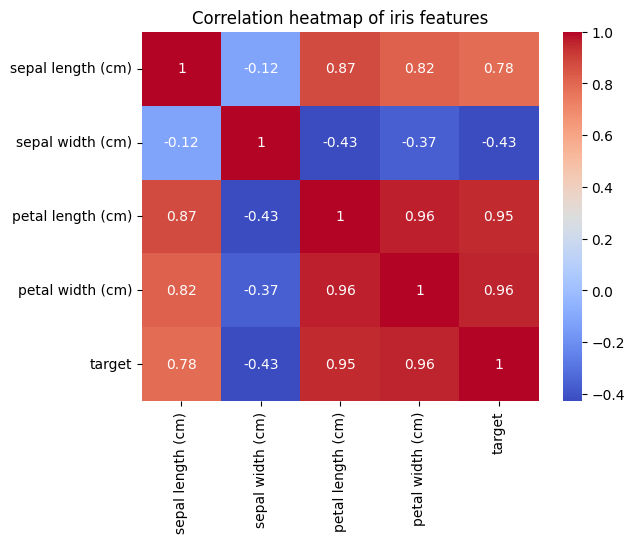

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation heatmap of iris features")

## e)
- gör en boxplot

In [47]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


<Axes: >

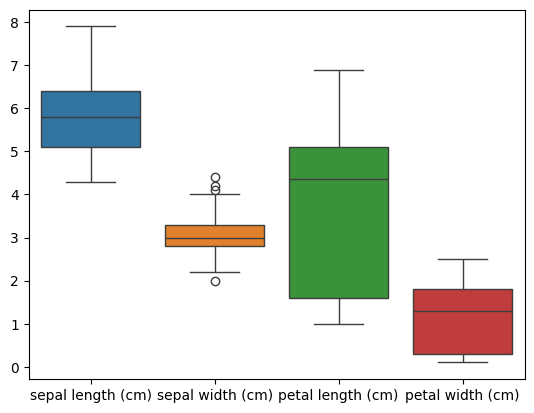

In [48]:
sns.boxplot(data=df.drop(columns='target'))

man kan se outliers på 'sepal width'

## f)

<Axes: >

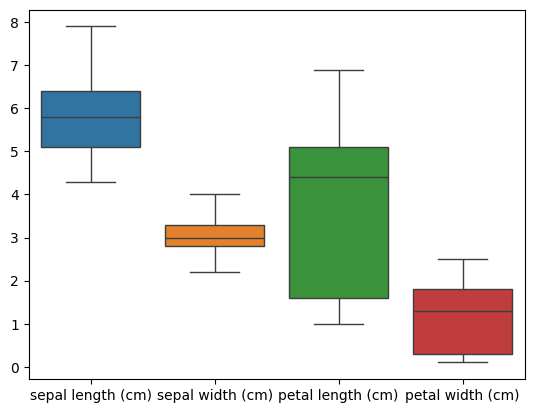

In [57]:
q1 = df['sepal width (cm)'].quantile(0.25)
q3 = df['sepal width (cm)'].quantile(0.75)
IQR = q3 - q1

# definera gränserna
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# filtrera bort outliers
df_cleaned = df[(df['sepal width (cm)'] >= lower_bound) & (df['sepal width (cm)'] <= upper_bound)]

sns.boxplot(data=df_cleaned.drop(columns='target'))

## g)
- här gör vi train|test split på datasetet och sen skalar vi med feature standardization

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# dela upp i egenskaper (X) och målvariabel (y)
X = df_cleaned.drop(columns='target')
y = df_cleaned['target']

In [66]:
# gör train|test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# standardisera
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## h)
- klassificera med logistic regression

In [67]:
from sklearn.linear_model import LogisticRegression

# skapa en instans av logistisk Logistisk Regression
model = LogisticRegression()

# träna modellen med ditt skalade träningsdata
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## i)
- klassificera dem 10 första values av X_test och jämför med label

In [69]:
# gissa arten för de 10 första blommorna i test-setet
predictions = model.predict(X_test_scaled[:10])

# hämta de faktiska etiketterna (facit) för samma blommor
actual_labels = y_test.iloc[:10].values

print(f"Modellens gissningar: {predictions}")
print(f"Faktiska etiketter: {actual_labels}")

Modellens gissningar: [0 2 0 0 0 2 0 1 2 0]
Faktiska etiketter: [0 2 0 0 0 2 0 1 1 0]


In [70]:
print("\nNamnjämnförelse")
for i in range(10):
    pred_name = iris.target_names[predictions[i]]
    actual_name = iris.target_names[actual_labels[i]]
    match = 'YES' if predictions[i] == actual_labels[i] else "FAIL"
    
    print(f"Blomma {i+1}: Gissning: {pred_name:10} | Faktiskt: {actual_name:10} {match}")


Namnjämnförelse
Blomma 1: Gissning: setosa     | Faktiskt: setosa     YES
Blomma 2: Gissning: virginica  | Faktiskt: virginica  YES
Blomma 3: Gissning: setosa     | Faktiskt: setosa     YES
Blomma 4: Gissning: setosa     | Faktiskt: setosa     YES
Blomma 5: Gissning: setosa     | Faktiskt: setosa     YES
Blomma 6: Gissning: virginica  | Faktiskt: virginica  YES
Blomma 7: Gissning: setosa     | Faktiskt: setosa     YES
Blomma 8: Gissning: versicolor | Faktiskt: versicolor YES
Blomma 9: Gissning: virginica  | Faktiskt: versicolor FAIL
Blomma 10: Gissning: setosa     | Faktiskt: setosa     YES


## j)
- evaluate modellen med användning av classification report and confusion matrix

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.91      0.95        11
   virginica       0.95      1.00      0.97        19

    accuracy                           0.98        49
   macro avg       0.98      0.97      0.98        49
weighted avg       0.98      0.98      0.98        49



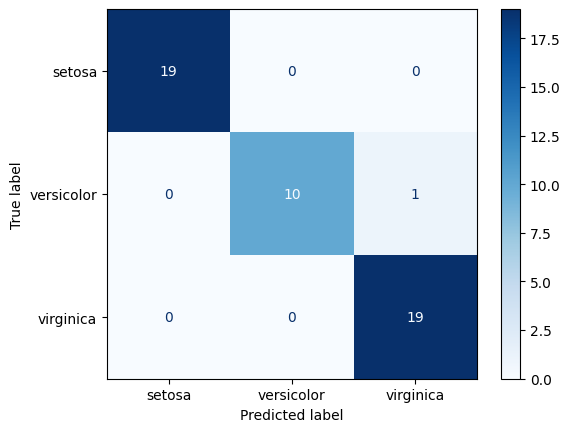

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# skapa prediktioner för hela test-setet
y_pred = model.predict(X_test_scaled)

# 1. skriv ut classification report
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 2. skapa och visa confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

disp.plot(cmap='Blues')